[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cca-cce/osm-comm/blob/main/jnb/skod52_template.ipynb)


# 1. Introduction

Motivate your CCA project by situating the problem in sustainability communication. Summarize key theoretical concepts and prior findings that inform your approach. State a clear purpose and formulate focused research questions and/or hypotheses that can be operationalized with a small, well-defined corpus.


Understanding how energy companies communicate sustainability is essential for analyzing how they justify their strategic decisions and maintain legitimacy in the face of environmental scrutiny. As a major actor in the global energy sector, **Equinor** uses its public website to present narratives about climate action, renewable investments, technological innovation, and responsibility within ongoing fossil-fuel operations. These texts are central to how the company frames its transition strategy and positions itself in relation to key stakeholders such as governments, communities, and investors.

This notebook reports a small-scale **computational content analysis (CCA)** of ten sustainability-related webpages from Equinor’s public website, converted to PDF and processed using NLP techniques (NER, POS tagging, aspect-based lexical analysis, concordances, and word-cloud visualizations). The goal is to demonstrate a transparent, replicable workflow for analyzing how corporate sustainability narratives are linguistically constructed.

### Research Questions and Hypotheses

**RQ1. How does Equinor frame its sustainability efforts in terms of future-oriented innovation versus present-focused responsibility?**
**H1.** *Future-oriented sustainability framing will appear more frequently than responsibility framing,* operationalized through higher frequency of POS patterns (e.g., modal verbs such as *will*, *can*, *aim to*) and lexical aspects related to innovation, technology, and transition.

**RQ2. Which stakeholder groups are most prominently featured in Equinor’s sustainability communication?**
**H2.** *Governmental and community stakeholders will be referenced more frequently than end-consumers or NGOs,* operationalized using NER outputs (e.g., ORG, GPE, NORP entities) and concordances around stakeholder-related keywords (e.g., *partners*, *communities*, *authorities*, *customers*).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

folder_path = '/content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor'
pdf_files = [f for f in os.listdir(folder_path) if f.endswith('.pdf')]

if pdf_files:
    print('PDF files in the folder:')
    for pdf in pdf_files:
        print(pdf)
else:
    print('No PDF files found in the specified folder.')

PDF files in the folder:
equinor09-energy-perspectives.pdf
equinor01-protecting-the-environment.pdf
equinor02-health-safety-and-security.pdf
equinor03-human-rights.pdf
equinor04-governance-and-transparency.pdf
equinor05-our-transition-ambitions.pdf
equinor06-a-just-energy-transition.pdf
equinor07-environmental-social-and-governance-esg-reporting-centre.pdf
equinor08-impact-assessments.pdf


In [3]:
!pip install -q PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.0 MB/s eta 0:00:00


Now, let's import the necessary libraries and define a function to extract text from a single PDF file.

In [4]:
import PyPDF2
import os

def extract_text_from_pdf(pdf_path):
    text = ""
    try:
        with open(pdf_path, 'rb') as file:
            reader = PyPDF2.PdfReader(file)
            for page_num in range(len(reader.pages)):
                page = reader.pages[page_num]
                text += page.extract_text() + "\n"
    except Exception as e:
        print(f"Error extracting text from {pdf_path}: {e}")
    return text

Next, I will iterate through the PDF files identified earlier, extract text from each, and store them in a dictionary where the keys are the filenames and the values are the extracted texts. I'll display the first 500 characters of each extracted text to give you a preview.

In [5]:
extracted_texts = {}
# Define the directory to save text files
save_directory = '/content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor/'
save_directory = '/content/'

for pdf_file in pdf_files:
    full_pdf_path = os.path.join(folder_path, pdf_file)
    print(f"Extracting text from: {full_pdf_path}")
    text_content = extract_text_from_pdf(full_pdf_path)
    extracted_texts[pdf_file] = text_content
    #print(f"Extracted text from {pdf_file} (first 500 chars):\n{text_content[:500]}\n")

    # Save the extracted text to a .txt file
    txt_filename = os.path.splitext(pdf_file)[0] + '.txt'
    txt_filepath = os.path.join(save_directory, txt_filename)
    with open(txt_filepath, 'w', encoding='utf-8') as f:
        f.write(text_content)
    print(f"Saved extracted text to: {txt_filepath}\n")

print(f"\nSuccessfully extracted text from {len(extracted_texts)} PDF files and saved to {save_directory}.")

Extracting text from: /content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor/equinor09-energy-perspectives.pdf
Saved extracted text to: /content/equinor09-energy-perspectives.txt

Extracting text from: /content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor/equinor01-protecting-the-environment.pdf
Saved extracted text to: /content/equinor01-protecting-the-environment.txt

Extracting text from: /content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor/equinor02-health-safety-and-security.pdf
Saved extracted text to: /content/equinor02-health-safety-and-security.txt

Extracting text from: /content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor/equinor03-human-rights.pdf
Saved extracted text to: /content/equinor03-human-rights.txt

Extracting text from: /content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor/equinor04-governance-and-transparency.pdf
Saved extracted text to: /content/equinor04-governance-and-transparency.txt

Extracting text from: /content/drive/MyDrive/doc/comm/skod52

# 2. Methods

Describe the dataset, sampling, and preprocessing pipeline (e.g., normalization, tokenization, stopwording, lemmatization). Explain chosen analyses (e.g., lexical statistics, collocations, NER) and justify parameter choices. Use text cells to connect each code cell to theory and to the research questions.

In [ ]:
!pip install -q spacy
!python -m spacy download en_core_web_sm -q


In [8]:
import spacy
import pandas as pd
import os
import re # Import the regular expression module

# Load the English spaCy model
nlp = spacy.load('en_core_web_sm')

# Define the directory where text files are saved
text_files_directory = '/content/'

# List all .txt files in the directory
txt_files = [f for f in os.listdir(text_files_directory) if f.endswith('.txt')]

sentence_data = []

for txt_file in txt_files:
    file_path = os.path.join(text_files_directory, txt_file)
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    doc = nlp(content)
    sentence_id = 0
    for sent in doc.sents:
        # Filter sentences with 3 words or more using regex for word count
        words = re.findall(r'\b\w+\b', sent.text) # Find all word tokens
        if len(words) >= 3:
            sentence_data.append({
                'text_id': txt_file,
                'sentence_id': sentence_id,
                'sentence_content': sent.text.strip()
            })
            sentence_id += 1

# Create a pandas DataFrame from the extracted sentence data
df_sentences = pd.DataFrame(sentence_data)

# Display the first few rows of the DataFrame
print("DataFrame df_sentences created successfully (first 5 rows):\n")
print(df_sentences.head())

# Save the DataFrame as a TSV file
tsv_filepath_sentences = os.path.join(text_files_directory, 'extracted_sentences.tsv')
df_sentences.to_csv(tsv_filepath_sentences, sep='\t', index=False)
print(f"\nDataFrame df_sentences saved as TSV to: {tsv_filepath_sentences}")

DataFrame df_sentences created successfully (first 5 rows):

                                  text_id  sentence_id  \
0  equinor05-our-transition-ambitions.txt            0   
1  equinor05-our-transition-ambitions.txt            1   
2  equinor05-our-transition-ambitions.txt            2   
3  equinor05-our-transition-ambitions.txt            3   
4  equinor05-our-transition-ambitions.txt            4   

                                    sentence_content  
0  Home>Sustainability>Energy transition plan\nEn...  
1  Menu\nPlan & strategy Ambitions People & natur...  
2  At Equinor, we are\ndedicated to delivering en...  
3  Our ambition is to be a leading company\nin th...  
4  Our plan\nOur Energy Transition Plan, original...  

DataFrame df_sentences saved as TSV to: /content/extracted_sentences.tsv


In [12]:
import pandas as pd
import spacy
import os

# Ensure the spaCy model is loaded
# nlp = spacy.load('en_core_web_sm') # Assuming nlp is already loaded from previous cells

# Load df_sentences if not already in memory (optional, for standalone execution)
# If running sequentially, df_sentences should already be available.
# text_files_directory = '/content/'
# tsv_filepath_sentences = os.path.join(text_files_directory, 'extracted_sentences.tsv')
# df_sentences = pd.read_csv(tsv_filepath_sentences, sep='\t')

tokens_data = []

for index, row in df_sentences.iterrows():
    text_id = row['text_id']
    sentence_id = row['sentence_id']
    sentence_content = row['sentence_content']

    doc = nlp(sentence_content)
    token_id = 0
    for token in doc:
        # Filter out stopwords, punctuation, and spaces. Removed 'not token.is_oov' condition.
        if not token.is_stop and not token.is_punct and not token.is_space:
            tokens_data.append({
                'text_id': text_id,
                'sentence_id': sentence_id,
                'token_id': token_id,
                'token_text': token.text.lower(),
                'token_lemma': token.lemma_,
                'token_ner': token.ent_type_,
                'token_pos': token.pos_
            })
            token_id += 1

# Create a pandas DataFrame from the extracted token data
df_tokens = pd.DataFrame(tokens_data)

# Display the first few rows of the DataFrame
print("DataFrame df_tokens created successfully (first 5 rows):\n")
print(df_tokens.head())

# Save the DataFrame as a TSV file
token_tsv_filepath = os.path.join(text_files_directory, 'extracted_tokens.tsv')
df_tokens.to_csv(token_tsv_filepath, sep='\t', index=False)
print(f"\nDataFrame df_tokens saved as TSV to: {token_tsv_filepath}")

DataFrame df_tokens created successfully (first 5 rows):

                                  text_id  sentence_id  token_id  \
0  equinor05-our-transition-ambitions.txt            0         0   
1  equinor05-our-transition-ambitions.txt            0         1   
2  equinor05-our-transition-ambitions.txt            0         2   
3  equinor05-our-transition-ambitions.txt            0         3   
4  equinor05-our-transition-ambitions.txt            0         4   

       token_text     token_lemma token_ner token_pos  
0            home            Home               PROPN  
1               >               >               PROPN  
2  sustainability  Sustainability               PROPN  
3               >               >               PROPN  
4          energy          Energy               PROPN  

DataFrame df_tokens saved as TSV to: /content/extracted_tokens.tsv


In [ ]:
# Install wordcloud if not already installed
!pip install -q wordcloud


Figure saved to: /content/wordclouds_top30.png


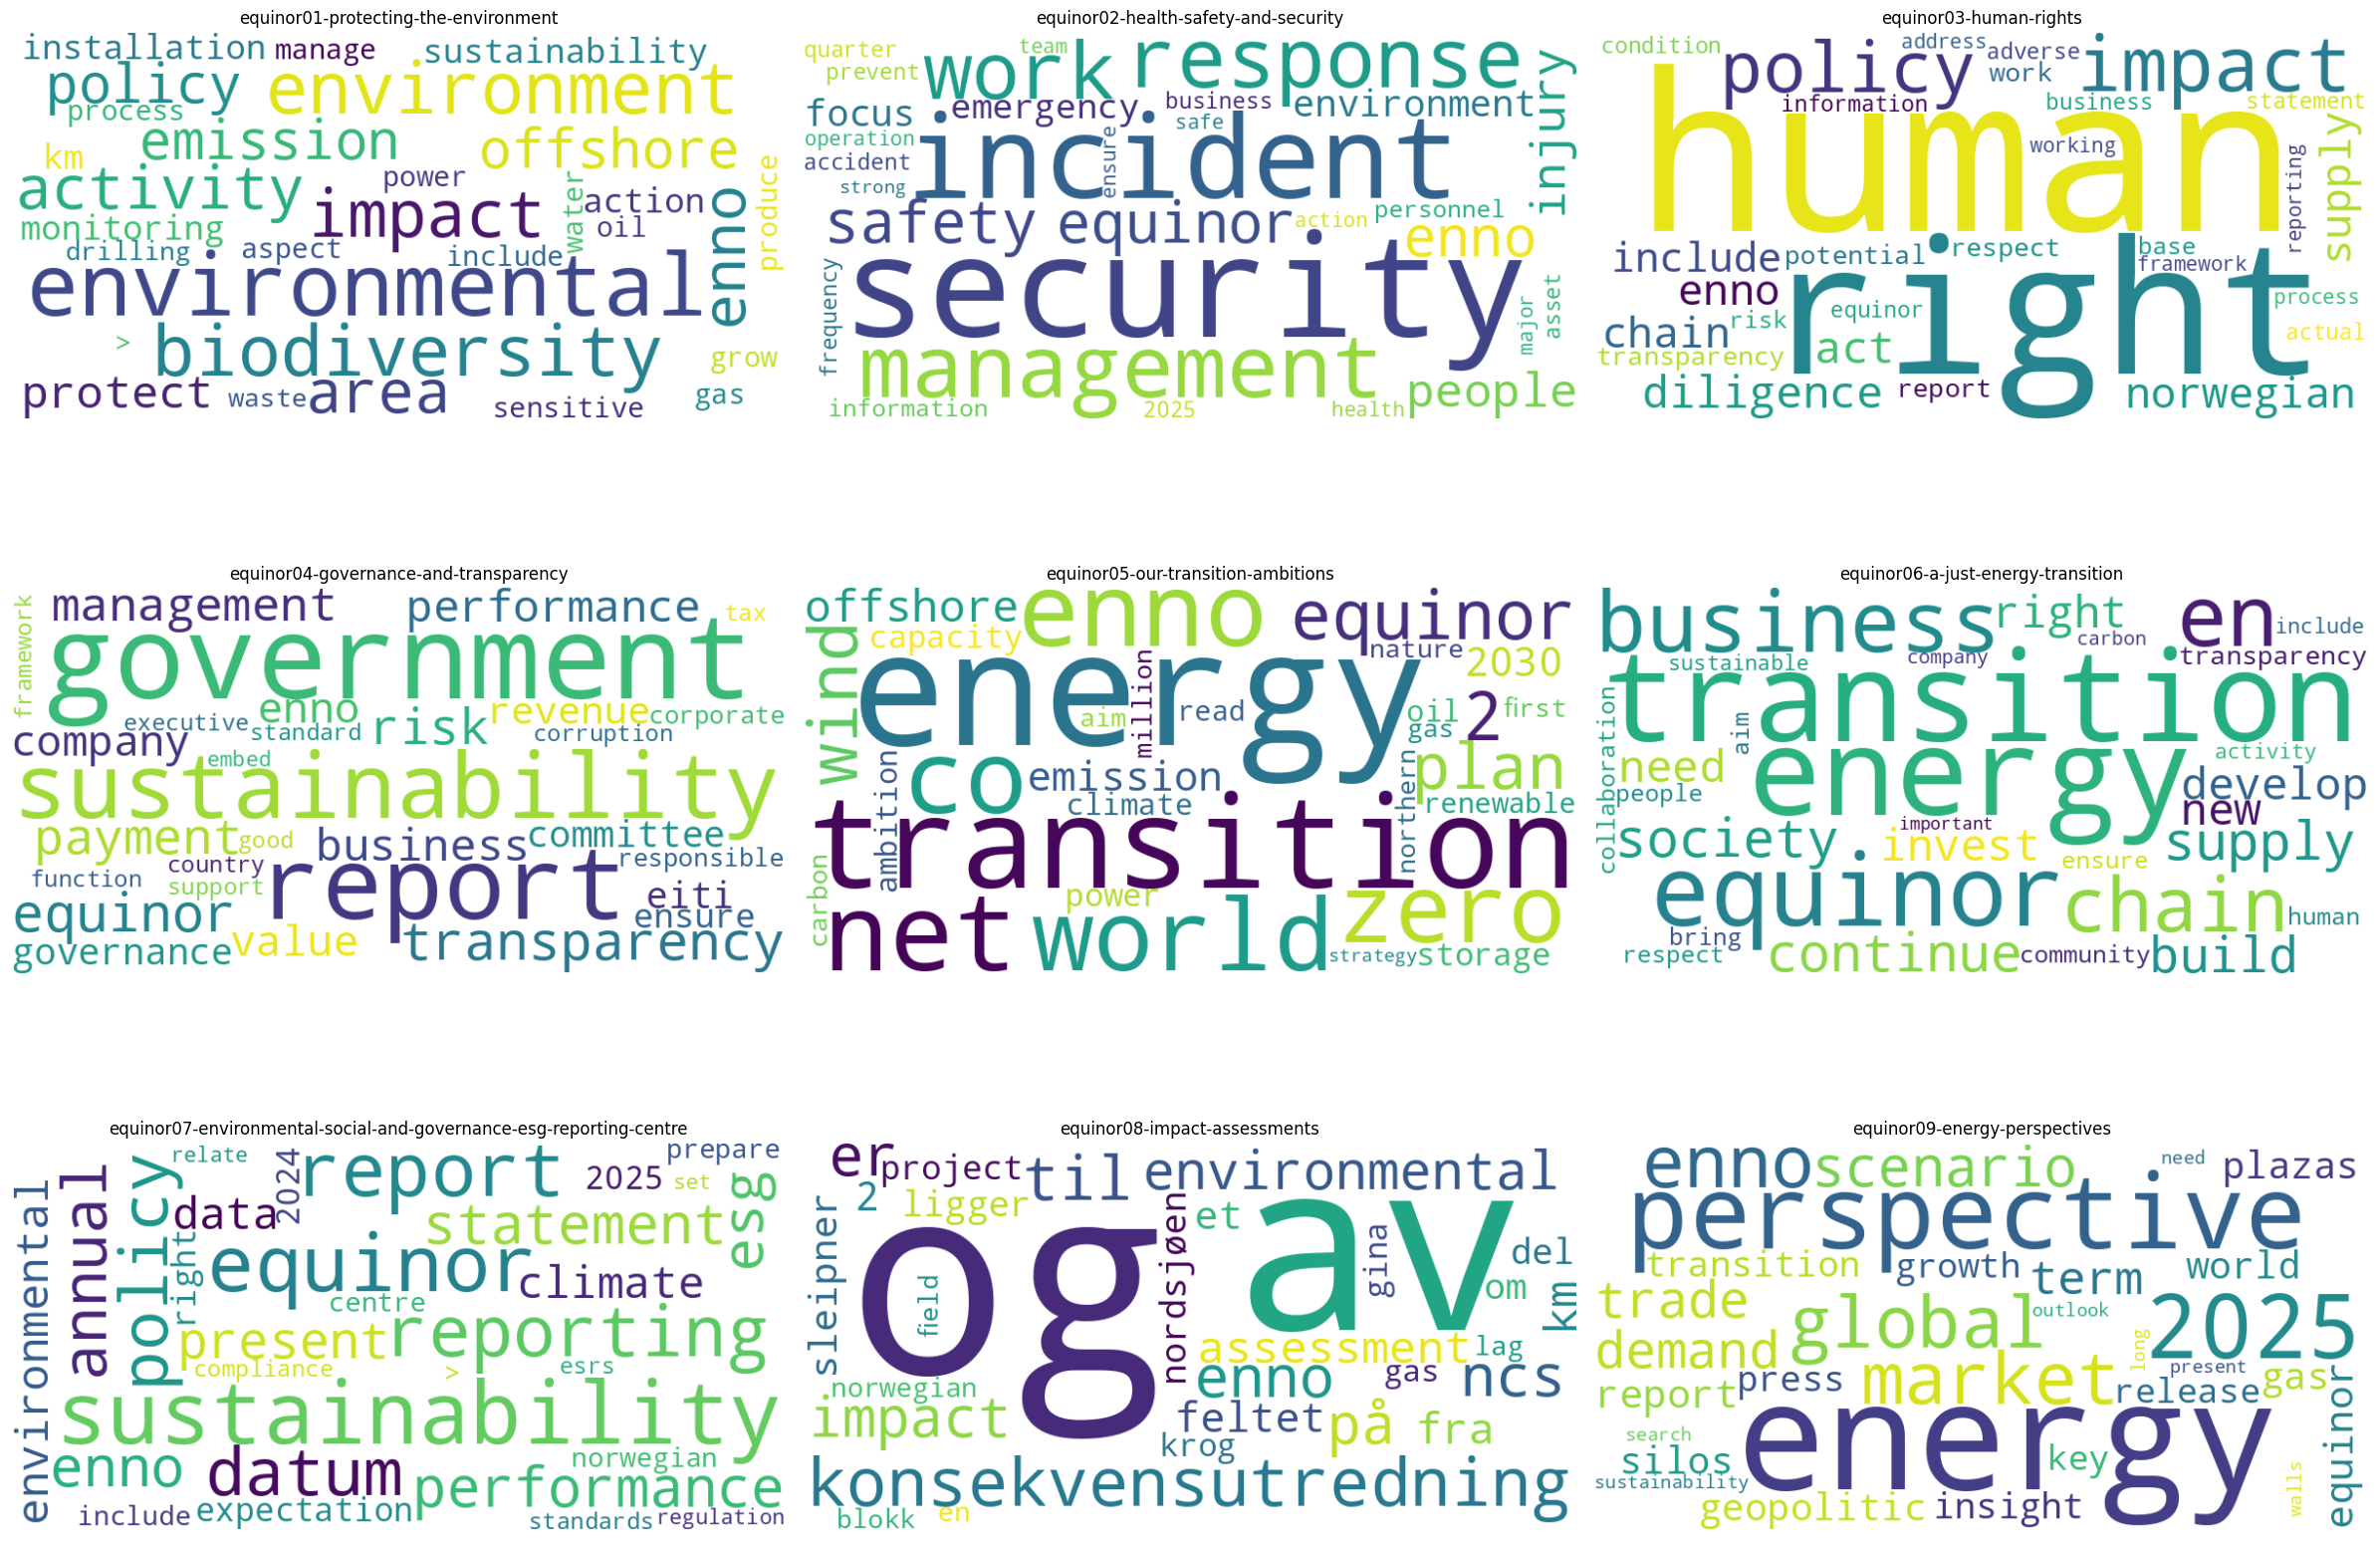

In [15]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import math
import os
from collections import Counter

# Group tokens by text_id and concatenate the token_lemma for each text
# Ensure lemmas are lowercased for consistent word cloud generation
text_lemmas_by_doc = df_tokens.groupby('text_id')['token_lemma'].apply(lambda x: [lemma.lower() for lemma in x])

# Determine the number of unique texts (for subplots)
n_texts = len(text_lemmas_by_doc)
n_cols = 3
n_rows = math.ceil(n_texts / n_cols)

# Create a figure and a set of subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 8, n_rows * 6))

# Flatten the axes array for easier iteration if there's more than one row/column
if n_rows > 1 or n_cols > 1:
    axes = axes.flatten()
else:
    axes = [axes] # Ensure it's iterable even for a single subplot

for i, (text_id, lemmas_list) in enumerate(text_lemmas_by_doc.items()):
    if i < len(axes):
        ax = axes[i]

        # Count word frequencies and get the 30 most common
        word_frequencies = Counter(lemmas_list)
        top_30_words = dict(word_frequencies.most_common(30))

        # Generate a word cloud from frequencies
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_30_words)

        # Display the generated image:
        ax.imshow(wordcloud, interpolation='bilinear')
        ax.set_title(text_id.replace('.txt', '')) # Clean up title
        ax.axis('off')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Save the figure to a high-resolution PNG file
save_directory = '/content/'
figure_filepath = os.path.join(save_directory, 'wordclouds_top30.png')
plt.savefig(figure_filepath, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filepath}")

plt.show()

In [17]:
import pandas as pd
import os

# Group by text_id, token_lemma, token_ner, token_pos and count occurrences
df_wordcloud = df_tokens.groupby(['text_id', 'token_lemma', 'token_ner', 'token_pos']).size().reset_index(name='token_frequency')

# Ensure token_lemma is lowercase (already done during df_tokens creation, but good for explicit confirmation)
df_wordcloud['token_lemma'] = df_wordcloud['token_lemma'].str.lower()

# Filter to include only the 30 most frequent tokens per text_id
df_wordcloud = df_wordcloud.groupby('text_id').apply(lambda x: x.nlargest(30, 'token_frequency')).reset_index(drop=True)

# Display the first few rows of the DataFrame
print("DataFrame df_wordcloud created successfully (first 5 rows):\n")
print(df_wordcloud.head())

# Save the DataFrame as a TSV file
save_directory = '/content/'
tsv_filepath_wordcloud = os.path.join(save_directory, 'df_wordcloud.tsv')
df_wordcloud.to_csv(tsv_filepath_wordcloud, sep='\t', index=False)
print(f"\nDataFrame df_wordcloud saved as TSV to: {tsv_filepath_wordcloud}")

DataFrame df_wordcloud created successfully (first 5 rows):

                                    text_id    token_lemma token_ner  \
0  equinor01-protecting-the-environment.txt  environmental             
1  equinor01-protecting-the-environment.txt   biodiversity             
2  equinor01-protecting-the-environment.txt    environment             
3  equinor01-protecting-the-environment.txt       activity             
4  equinor01-protecting-the-environment.txt           area             

  token_pos  token_frequency  
0       ADJ                9  
1      NOUN                7  
2      NOUN                6  
3      NOUN                5  
4      NOUN                5  

DataFrame df_wordcloud saved as TSV to: /content/df_wordcloud.tsv


/tmp/ipython-input-3788725263.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_wordcloud = df_wordcloud.groupby('text_id').apply(lambda x: x.nlargest(30, 'token_frequency')).reset_index(drop=True)


# 3. Results

Present concise summary tables and intuitive visualizations that address each research question. Contrast expected outcomes with empirical patterns and highlight notable divergences. Ensure figures are readable in Colab, labeled clearly, and interpretable without additional code inspection.

# 4. Discussion

Interpret findings relative to theory and prior research, noting implications for sustainability communication practice. Propose realistic content improvements and hypotheses about optimizing cognitive communication effects. Acknowledge limitations (data size, methods) and outline concrete next steps for validation.